In [28]:
import pandas as pd

In [29]:
df = pd.read_csv("dataset_sig_st.csv")

In [30]:
df.columns

Index(['D1_daily_screen', 'age_class', 'A2_gender', 'B1_residence',
       'income_class', 'weight_class', 'D2_weekend_screen', 'D4_content',
       'D5_parents_screen_time', 'D6_ai_daily', 'E5_bedtime', 'E6_wake_time',
       'F1_academic_satisfaction', 'F4_interest_reduced', 'G1_mood_swings',
       'G2_anxious_without_device', 'H1_mobile_while_eating',
       'H2_appetite_change', 'BMI_class', 'D4_content_grouped'],
      dtype='str')

In [31]:

# Check target variable distribution
print("Target variable: D1_daily_screen")
print(df['D1_daily_screen'].value_counts())
print("\nShape:", df.shape)
print("\nMissing values:\n", df.isnull().sum().sum())


Target variable: D1_daily_screen
D1_daily_screen
1-3 hours            137
3-5 hours            125
Less than 1 hour     112
More than 5 hours     78
Name: count, dtype: int64

Shape: (452, 20)

Missing values:
 0


## Multinomial Logistic Regression — Target: `D1_daily_screen`

In [32]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [33]:
#  1. Prepare features and target
target = 'D1_daily_screen'
features = [c for c in df.columns if c != target]

X = df[features].copy()
y = df[target].copy()

# Encode every categorical column with a fresh LabelEncoder
encoders = {}
for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

le_target = LabelEncoder()
y_enc = le_target.fit_transform(y.astype(str))
class_names = le_target.classes_

print("Classes:", class_names)
print("Encoded labels:", np.unique(y_enc))


Classes: ['1-3 hours' '3-5 hours' 'Less than 1 hour' 'More than 5 hours']
Encoded labels: [0 1 2 3]


In [34]:

# 2. Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")


Train size: 361  |  Test size: 91


In [35]:

# 3. Fit Multinomial Logistic Regression
mlr = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
mlr.fit(X_train, y_train)
y_pred = mlr.predict(X_test)

# 4. Evaluation 
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


Test Accuracy: 0.4615 (46.15%)

Classification Report:
                   precision    recall  f1-score   support

        1-3 hours       0.45      0.50      0.47        28
        3-5 hours       0.42      0.56      0.48        25
 Less than 1 hour       0.56      0.45      0.50        22
More than 5 hours       0.44      0.25      0.32        16

         accuracy                           0.46        91
        macro avg       0.47      0.44      0.44        91
     weighted avg       0.47      0.46      0.46        91



### Odds Ratios (per class vs. reference)

In [36]:

# Odds Ratios 
# OR = exp(coefficient); OR > 1 → increases odds of that class, < 1 → decreases
odds_ratio_df = pd.DataFrame(
    np.exp(mlr.coef_),
    index=class_names,
    columns=features
).T

print("Odds Ratios per class (rows=features, columns=D1_daily_screen classes):\n")
print(odds_ratio_df.round(4).to_string())


Odds Ratios per class (rows=features, columns=D1_daily_screen classes):

                           1-3 hours  3-5 hours  Less than 1 hour  More than 5 hours
age_class                     0.5777     1.2550            0.6741             2.0460
A2_gender                     0.8782     1.9621            0.5166             1.1234
B1_residence                  0.5560     1.2007            0.9297             1.6111
income_class                  0.7435     0.8898            1.8285             0.8266
weight_class                  1.1612     0.6719            1.2224             1.0485
D2_weekend_screen             1.4887     0.1612           22.1058             0.1885
D4_content                    0.9325     1.0581            1.0223             0.9914
D5_parents_screen_time        1.1685     0.9619            1.9095             0.4659
D6_ai_daily                   0.8741     1.1740            1.0356             0.9409
E5_bedtime                    1.0140     0.9110            1.6431            

In [37]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import MNLogit

# Refit using statsmodels to get standard errors, p-values, and CIs
X_sm = sm.add_constant(X.values.astype(float))
feature_names_sm = ['const'] + features

mnl = MNLogit(y_enc, X_sm)
result = mnl.fit(method='bfgs', maxiter=2000, disp=False)

ref_class = class_names[0]
eq_classes = class_names[1:]

rows = []
for eq_idx, cls in enumerate(eq_classes):
    coefs = result.params[:, eq_idx]
    se    = result.bse[:, eq_idx]
    pvals = result.pvalues[:, eq_idx]

    for feat_idx, feat in enumerate(feature_names_sm):
        if feat == 'const':
            continue
        b = coefs[feat_idx]
        s = se[feat_idx]
        rows.append({
            'Class (vs. reference)': f"{cls}  vs.  {ref_class}",
            'Feature':               feat,
            'Odds Ratio':            round(np.exp(b), 4),
            'Lower 95% CI':          round(np.exp(b - 1.96 * s), 4),
            'Upper 95% CI':          round(np.exp(b + 1.96 * s), 4),
            'p-value':               round(pvals[feat_idx], 4),
        })

or_table = pd.DataFrame(rows)

pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
print("Odds Ratio Table — Multinomial Logistic Regression")
print(f"Reference class: '{ref_class}'\n")
print(or_table.to_string(index=False))


Odds Ratio Table — Multinomial Logistic Regression
Reference class: '1-3 hours'

            Class (vs. reference)                   Feature  Odds Ratio  Lower 95% CI  Upper 95% CI  p-value
        3-5 hours  vs.  1-3 hours                 age_class      2.7579        1.6005        4.7523   0.0003
        3-5 hours  vs.  1-3 hours                 A2_gender      2.8107        1.2598        6.2708   0.0116
        3-5 hours  vs.  1-3 hours              B1_residence      3.8463        1.5763        9.3852   0.0031
        3-5 hours  vs.  1-3 hours              income_class      1.0416        0.6790        1.5979   0.8517
        3-5 hours  vs.  1-3 hours              weight_class      0.9077        0.5392        1.5281   0.7156
        3-5 hours  vs.  1-3 hours         D2_weekend_screen      0.0515        0.0177        0.1502   0.0000
        3-5 hours  vs.  1-3 hours                D4_content      1.0484        0.8922        1.2320   0.5656
        3-5 hours  vs.  1-3 hours    D5_parents

In [38]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

output_pdf = "report_v3/odds_ratio_table_st.pdf"

col_widths = [0.30, 0.22, 0.12, 0.13, 0.13, 0.10]
row_height = 0.32   # inches per row
header_height = 0.55
rows_per_page = 40

pages = [or_table.iloc[i:i+rows_per_page] for i in range(0, len(or_table), rows_per_page)]

with PdfPages(output_pdf) as pdf:
    for page_num, page_df in enumerate(pages):
        n_rows = len(page_df)
        fig_h = header_height + n_rows * row_height + 1.2
        fig, ax = plt.subplots(figsize=(14, fig_h))
        ax.axis('off')

        table_data = [or_table.columns.tolist()] + page_df.values.tolist()
        col_labels = or_table.columns.tolist()

        tbl = ax.table(
            cellText=page_df.values.tolist(),
            colLabels=col_labels,
            colWidths=col_widths,
            loc='center',
            cellLoc='center',
        )
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(7.5)
        tbl.scale(1, 1.4)

        # Style header
        for col_idx in range(len(col_labels)):
            cell = tbl[0, col_idx]
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', fontweight='bold')

        # Alternating row shading
        for row_idx in range(1, n_rows + 1):
            for col_idx in range(len(col_labels)):
                cell = tbl[row_idx, col_idx]
                cell.set_facecolor('#f2f2f2' if row_idx % 2 == 0 else 'white')
                cell.set_edgecolor('#cccccc')

        total_pages = len(pages)
        ax.set_title(
            f"Odds Ratio Table — Multinomial Logistic Regression\n"
            f"Reference class: '{ref_class}'   |   Page {page_num+1} of {total_pages}",
            fontsize=10, fontweight='bold', pad=12
        )
        plt.tight_layout()
        pdf.savefig(fig, bbox_inches='tight')
        plt.close(fig)

print(f"Saved: {output_pdf}  ({len(pages)} page(s), {len(or_table)} rows)")


Saved: report_v3/odds_ratio_table_st.pdf  (2 page(s), 57 rows)


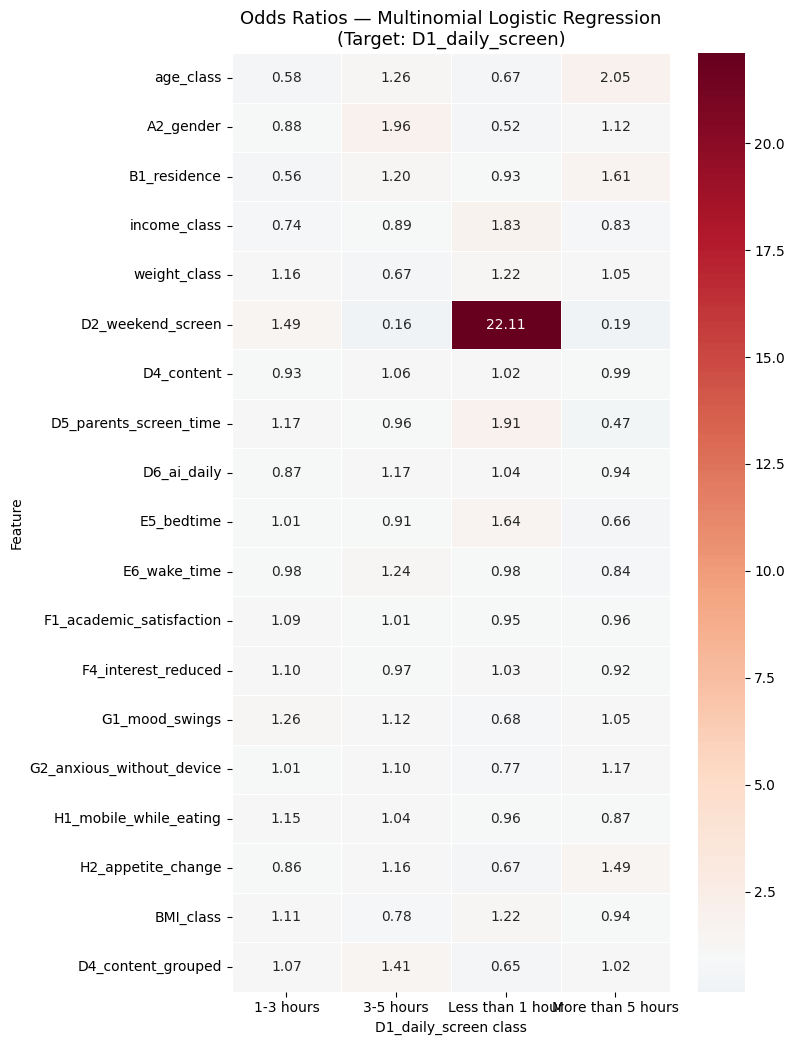

In [39]:

# Odds Ratio Heatmap 
import seaborn as sns

fig, ax = plt.subplots(figsize=(max(8, len(class_names) * 2), len(features) * 0.45 + 2))
sns.heatmap(
    odds_ratio_df,
    annot=True, fmt=".2f",
    center=1.0,
    cmap="RdBu_r",
    linewidths=0.4,
    ax=ax
)
ax.set_title("Odds Ratios — Multinomial Logistic Regression\n(Target: D1_daily_screen)", fontsize=13)
ax.set_xlabel("D1_daily_screen class")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()


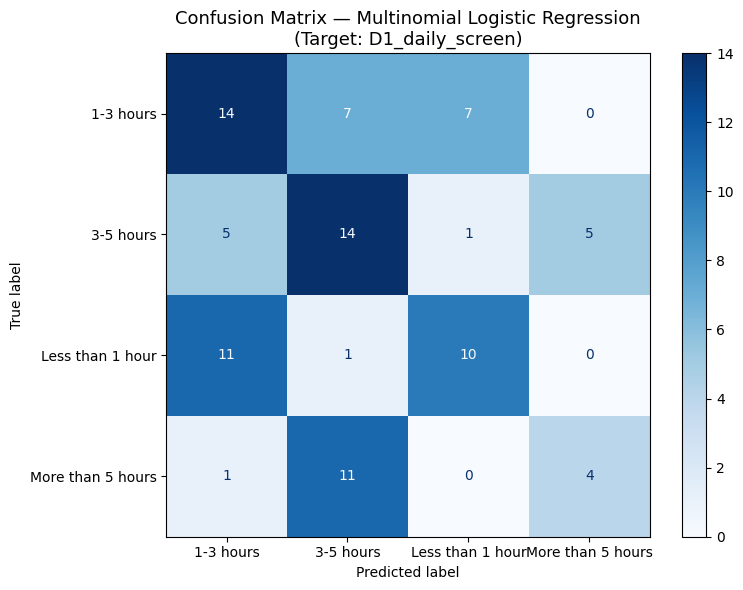

In [40]:

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title("Confusion Matrix — Multinomial Logistic Regression\n(Target: D1_daily_screen)", fontsize=13)
plt.tight_layout()
plt.show()


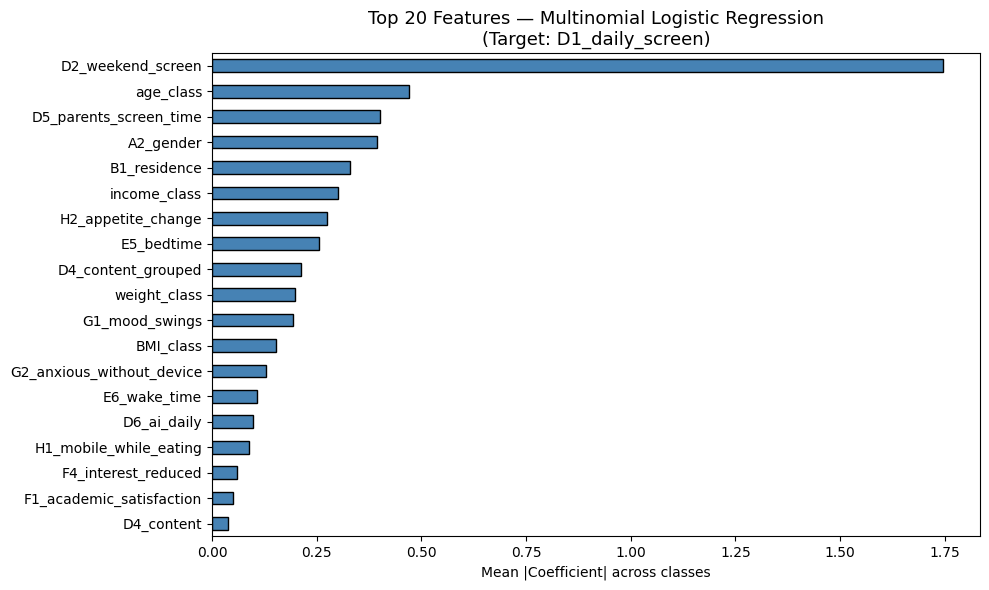


Top 15 features by mean absolute coefficient:
                           mean_abs
D2_weekend_screen            1.7469
age_class                    0.4715
D5_parents_screen_time       0.4013
A2_gender                    0.3952
B1_residence                 0.3299
income_class                 0.3018
H2_appetite_change           0.2744
E5_bedtime                   0.2553
D4_content_grouped           0.2137
weight_class                 0.1988
G1_mood_swings               0.1940
BMI_class                    0.1538
G2_anxious_without_device    0.1279
E6_wake_time                 0.1081
D6_ai_daily                  0.0977
H1_mobile_while_eating       0.0884
F4_interest_reduced          0.0608
F1_academic_satisfaction     0.0492
D4_content                   0.0393


In [41]:

# 6. Feature Importance (Coefficients)
coef_df = pd.DataFrame(
    mlr.coef_,
    index=class_names,
    columns=features
).T

# Mean absolute coefficient across classes → overall importance
coef_df['mean_abs'] = coef_df.abs().mean(axis=1)
coef_df_sorted = coef_df.sort_values('mean_abs', ascending=False)

top_n = 20
fig, ax = plt.subplots(figsize=(10, 6))
coef_df_sorted['mean_abs'].head(top_n).sort_values().plot(
    kind='barh', ax=ax, color='steelblue', edgecolor='black'
)
ax.set_xlabel("Mean |Coefficient| across classes")
ax.set_title(f"Top {top_n} Features — Multinomial Logistic Regression\n(Target: D1_daily_screen)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nTop 15 features by mean absolute coefficient:")
print(coef_df_sorted[['mean_abs']].head(top_n).to_string())
